# Gemma 4 E4B — leitura, correção, simplificação e leitura guiada

Notebook simplificado e reutilizável para:
1. Ler o texto da imagem com **Gemma 4 E4B IT**
2. Fazer um passo de **cleanup OCR**
3. Gerar **linhas de leitura** do texto corrigido
4. Gerar **texto simplificado**
5. Gerar **linhas de leitura** do texto simplificado
6. Navegar pelos dois modos de leitura

Este notebook foi mantido o mais próximo possível da versão anterior, mas com:
- funções reutilizáveis
- comentários curtos
- menos repetição de código
- pipeline mais claro

In [1]:
# Instalação base (Kaggle / Colab style)
!pip install -q -U transformers accelerate gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 66.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.1 MB/s eta 0:00:00:00:01


In [2]:
import os
import re
import json
import time
import torch
import kagglehub
import gradio as gr

from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets


In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

# Modelo escolhido
#MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")
MODEL_PATH = "google/gemma-4-E4B-it"
# Ficheiro de imagem (mantém o mesmo tipo de caminho Kaggle)
IMAGE_PATH = "/kaggle/input/datasets/eduardocatarino/dyslexia/hgp3.jpg"

# Limites de geração
MAX_TOKENS_TRANSCRIPTION = 2048
MAX_TOKENS_CLEANUP = 2048
MAX_TOKENS_READING = 1536
MAX_TOKENS_SIMPLIFY = 1536

In [4]:
# ============================================================
# CARREGAMENTO DO MODELO
# ============================================================

from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained(MODEL_PATH)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    torch_dtype="auto",
    device_map="auto"
)
print("Modelo carregado com sucesso.")

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Modelo carregado com sucesso.


In [5]:
# ============================================================
# FUNÇÕES GERAIS
# ============================================================

def generate_response(messages, images=None, max_new_tokens=1024):
    """Gera uma resposta do modelo para mensagens com ou sem imagem."""
    chat_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    if images is not None:
        inputs = processor(
            text=chat_text,
            images=images,
            return_tensors="pt"
        )
    else:
        inputs = processor(
            text=chat_text,
            return_tensors="pt"
        )

    # Envia tensores para o dispositivo do modelo
    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_tokens = outputs[:, inputs["input_ids"].shape[-1]:]
    response = processor.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    return response.strip()


def extract_section(text, section_name):
    """Extrai uma secção no formato SECÇÃO: ..."""
    pattern = rf"{section_name}:\s*(.*?)(?=\n[A-Z_]+:|$)"
    match = re.search(pattern, text, re.DOTALL)
    return match.group(1).strip() if match else ""


def extract_main_text(response_text):
    return extract_section(response_text, "TEXTO_PRINCIPAL")


def extract_corrected_text(response_text):
    return extract_section(response_text, "TEXTO_CORRIGIDO")


def extract_simplified_text(response_text):
    return extract_section(response_text, "SIMPLIFIED")


def extract_reading_lines(response_text):
    """Extrai linhas numeradas da secção LINHAS_DE_LEITURA."""
    block = extract_section(response_text, "LINHAS_DE_LEITURA")
    lines = []

    for line in block.split("\n"):
        line = re.sub(r"^\s*\d+[.)-]?\s*", "", line).strip()
        if line:
            lines.append(line)

    return lines


def fallback_split_lines_keep_bullets(text):
    """Fallback simples caso o modelo não devolva as linhas no formato esperado."""
    raw_lines = [line.strip() for line in text.split("\n") if line.strip()]
    final_lines = []

    for line in raw_lines:
        if line.startswith("* ") or line.startswith("• ") or line.startswith("- "):
            final_lines.append(line)
        else:
            parts = re.split(r'(?<=[.!?;:])\s+', line)
            final_lines.extend([p.strip() for p in parts if p.strip()])

    return final_lines

def normalize_text(text):
    if not text:
        return ""
    text = text.replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()


def split_into_lines_contract(text):
    text = normalize_text(text)
    if not text:
        return []

    explicit_lines = [line.strip() for line in text.split("\n") if line.strip()]
    if len(explicit_lines) > 1:
        return explicit_lines

    sentence_lines = re.findall(r"[^.!?]+[.!?]?", text)
    sentence_lines = [line.strip() for line in sentence_lines if line.strip()]
    return sentence_lines if sentence_lines else [text]


def ensure_contract_shape(original_text, simplified_text, provider="kaggle", extra_meta=None):
    original_text = normalize_text(original_text)
    simplified_text = normalize_text(simplified_text)

    meta = {"provider": provider}
    if extra_meta:
        meta.update(extra_meta)

    return {
        "success": True,
        "original_text": original_text,
        "simplified_text": simplified_text,
        "original_lines": split_into_lines_contract(original_text),
        "simplified_lines": split_into_lines_contract(simplified_text),
        "meta": meta,
    }


In [6]:
# ============================================================
# PROMPTS
# ============================================================

transcription_prompt = """
Lê o texto presente na imagem de uma página de manual escolar.

Tarefa:
- Transcreve o texto de forma fiel.

Regras:
- Mantém títulos e subtítulos separados.
- Mantém listas com um item por linha.
- Preserva listas com marcadores.
- Não transformes listas em texto corrido.
- Mantém a ordem natural de leitura (de cima para baixo, esquerda para direita).
- Se existir uma caixa lateral, transcreve-a no fim.
- Não resumas.
- Não expliques.
- Não acrescentes informação nova.
- Não retires informação.
- Não reorganizes o texto.
- Mantém a estrutura original.
- Não uses markdown.
- Não coloques negrito.
- Não coloques itálico.
- Não acrescentes parênteses onde não existiam.
- Usa português europeu.

Devolve exatamente neste formato:

TEXTO_PRINCIPAL:
...
"""


cleanup_prompt_template = """
Corrige o texto extraído de uma imagem.

Objetivo:
- Corrigir erros prováveis de OCR.
- Corrigir palavras partidas por mudança de linha.
- Corrigir caracteres mal reconhecidos quando a correção for muito provável.

Regras:
- Não resumas.
- Não expliques.
- Não acrescentes informação nova.
- Não retires informação.
- Não reorganizes o texto.
- Mantém títulos, subtítulos e listas.
- Mantém cada item da lista numa linha separada.
- Não uses markdown.
- Usa português europeu.
- Se uma palavra estiver ambígua, mantém a forma original.

Texto:
{raw_text}

Devolve exatamente neste formato:

TEXTO_CORRIGIDO:
...
"""


reading_prompt_original_template = """
És um assistente de leitura para um aluno de 12 anos com dislexia.

Tarefa:
- Organiza o texto em linhas de leitura.
- Mantém o conteúdo o mais próximo possível do original.

Regras:
- Não resumas.
- Não expliques.
- Não acrescentes informação nova.
- Não retires informação importante.
- Mantém nomes, datas e factos.
- Cada linha deve conter apenas uma ideia.
- Usa frases curtas.
- Mantém listas com um item por linha.
- Usa português europeu.
- Não uses markdown.

Texto:
{input_text}

Devolve exatamente neste formato:

LINHAS_DE_LEITURA:
1. ...
2. ...
3. ...
"""


simplify_prompt_template = """
És um assistente de leitura para um aluno de 12 anos com dislexia.

Tarefa:
- Reescreve o texto para facilitar a compreensão.

Regras:
- Mantém o significado original.
- Não acrescentes informação nova.
- Não retires factos importantes.
- Mantém nomes, datas e factos essenciais.
- Usa frases mais simples.
- Usa português europeu.
- Não uses markdown.
- Não resolvas exercícios.

Texto:
{input_text}

Devolve exatamente neste formato:

SIMPLIFIED:
...
"""


reading_prompt_simplified_template = """
És um assistente de leitura para um aluno de 12 anos com dislexia.

Tarefa:
- Organiza o texto simplificado em linhas de leitura.

Regras:
- Cada linha deve conter apenas uma ideia.
- Usa frases curtas.
- Mantém o significado do texto simplificado.
- Não acrescentes informação nova.
- Mantém listas com um item por linha.
- Usa português europeu.
- Não uses markdown.

Texto:
{input_text}

Devolve exatamente neste formato:

LINHAS_DE_LEITURA:
1. ...
2. ...
3. ...
"""

In [7]:
def prepare_image_for_model(image, max_side=1400):
    """
    Reduz a imagem se for demasiado grande, mantendo proporções.
    Ajuda a evitar OOM no passo visual.
    """
    img = image.convert("RGB").copy()
    w, h = img.size
    longest_side = max(w, h)

    if longest_side > max_side:
        scale = max_side / longest_side
        new_size = (int(w * scale), int(h * scale))
        img = img.resize(new_size, Image.Resampling.LANCZOS)

    return img

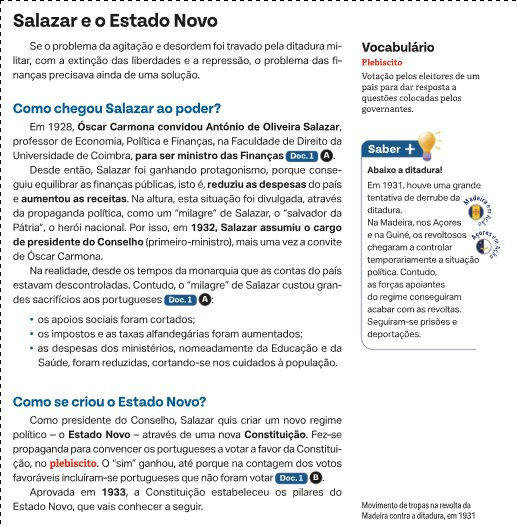

Tamanho original: (517, 527)
Tamanho para inferência: (517, 527)


In [8]:
image = Image.open(IMAGE_PATH).convert("RGB")
display(image)

# imagem usada na inferência
model_image = prepare_image_for_model(image, max_side=1400)

print("Tamanho original:", image.size)
print("Tamanho para inferência:", model_image.size)

In [9]:
from PIL import Image, ImageOps, ImageEnhance, ImageFilter

def preprocess_for_reading(
    image,
    crop_box=None,
    grayscale=True,
    autocontrast=True,
    contrast_factor=1.4,
    sharpness_factor=1.2,
    upscale=1.5,
    max_size=1600
):
    img = image.convert("RGB")

    # 1) Crop opcional
    if crop_box is not None:
        img = img.crop(crop_box)

    # 2) Escala de cinzentos
    if grayscale:
        img = ImageOps.grayscale(img)

    # 3) Autocontrast
    if autocontrast:
        img = ImageOps.autocontrast(img)

    # 4) Contraste
    if contrast_factor != 1.0:
        img = ImageEnhance.Contrast(img).enhance(contrast_factor)

    # 5) Nitidez
    if sharpness_factor != 1.0:
        img = ImageEnhance.Sharpness(img).enhance(sharpness_factor)

    # 6) Pequeno filtro extra
    img = img.filter(ImageFilter.SHARPEN)

    # 7) Upscale moderado
    if upscale and upscale != 1.0:
        new_w = int(img.width * upscale)
        new_h = int(img.height * upscale)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # 8) Limitar tamanho máximo para não explodir a inferência
    longest_side = max(img.width, img.height)
    if longest_side > max_size:
        scale = max_size / longest_side
        img = img.resize(
            (int(img.width * scale), int(img.height * scale)),
            Image.Resampling.LANCZOS
        )

    # garantir RGB no fim
    img = img.convert("RGB")
    return img

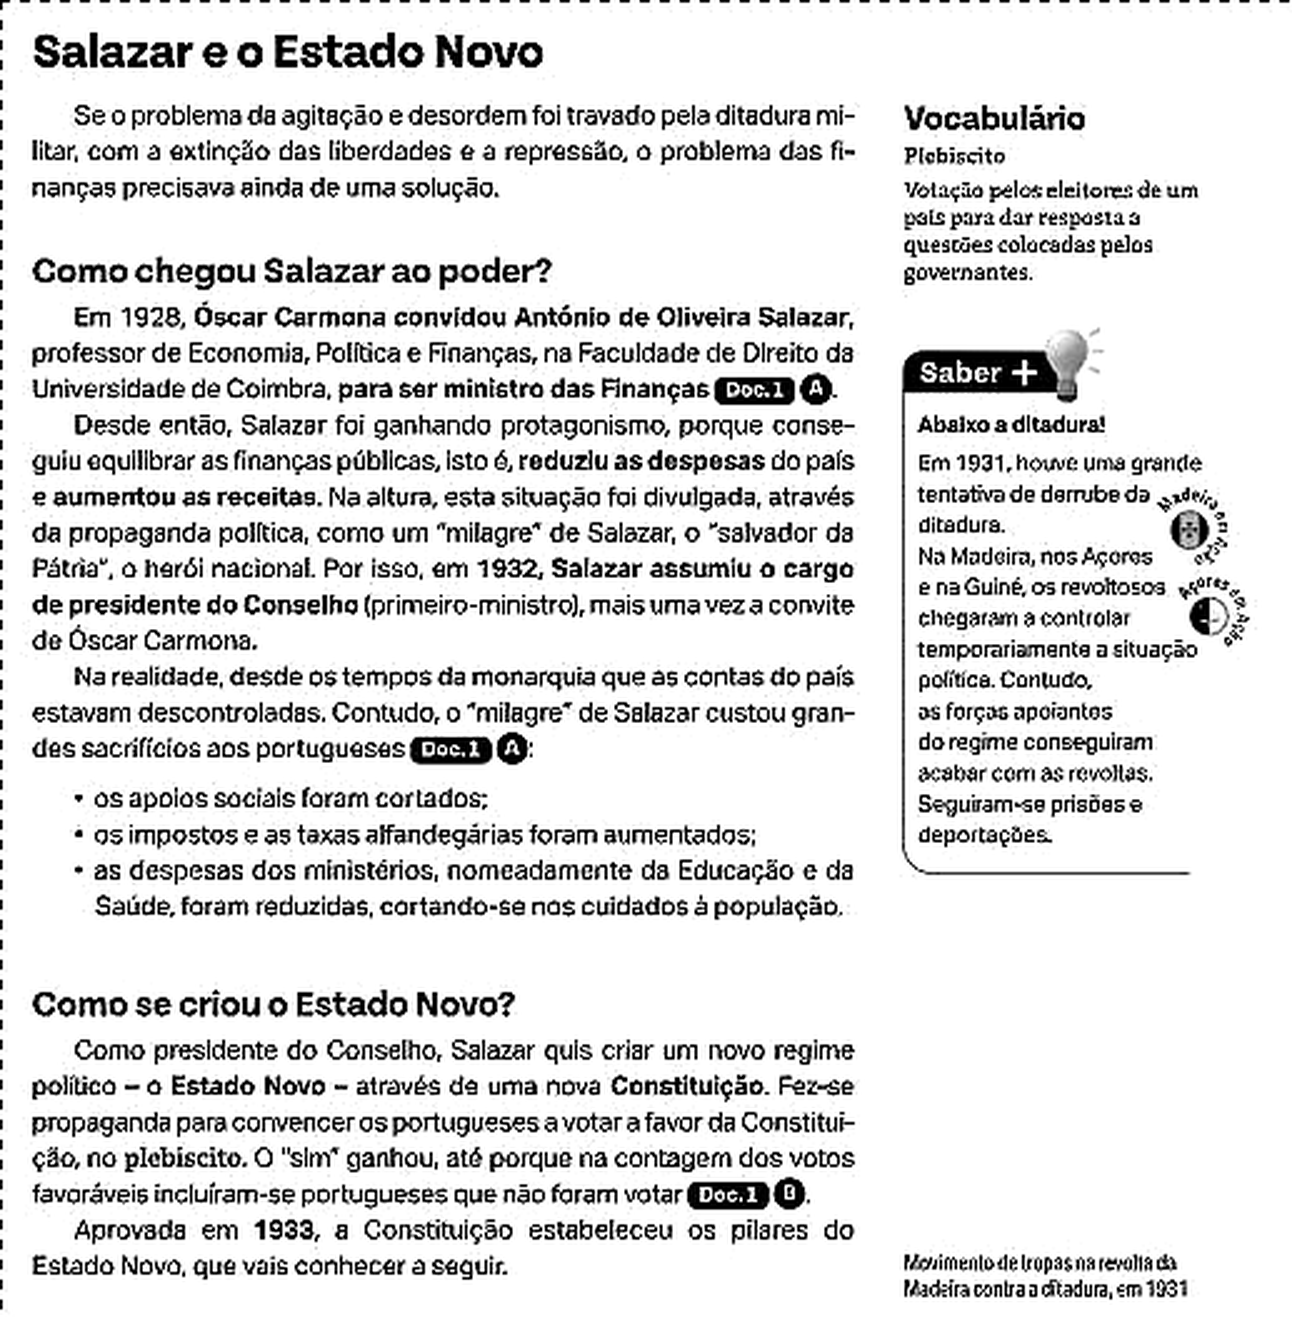

In [10]:
image = Image.open(IMAGE_PATH).convert("RGB")
processed_image = preprocess_for_reading(
    image,
    grayscale=True,
    contrast_factor=1.5,
    sharpness_factor=1.3,
    upscale=2.5,
    max_size=1400
)

display(processed_image)

In [11]:
# ============================================================
# FUNÇÕES DO PIPELINE
# ============================================================

def transcribe_image(image):
    """Passo 1: transcrição fiel da imagem."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": transcription_prompt},
            ],
        }
    ]

    response = generate_response(
        messages,
        images=image,
        max_new_tokens=MAX_TOKENS_TRANSCRIPTION
    )

    text = extract_main_text(response)
    if not text:
        text = response.strip()

    return response, text


def cleanup_text(raw_text):
    """Passo 2: cleanup OCR sobre o texto extraído."""
    cleanup_prompt = cleanup_prompt_template.format(raw_text=raw_text)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": cleanup_prompt},
            ],
        }
    ]

    response = generate_response(
        messages,
        images=None,
        max_new_tokens=MAX_TOKENS_CLEANUP
    )

    text = extract_corrected_text(response)
    if not text:
        text = raw_text

    return response, text


def build_reading_lines(input_text, simplified=False):
    """Passo 3 ou 5: gera linhas de leitura."""
    prompt = (
        reading_prompt_simplified_template.format(input_text=input_text)
        if simplified
        else reading_prompt_original_template.format(input_text=input_text)
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
            ],
        }
    ]

    response = generate_response(
        messages,
        images=None,
        max_new_tokens=MAX_TOKENS_READING
    )

    lines = extract_reading_lines(response)
    if not lines:
        lines = fallback_split_lines_keep_bullets(input_text)

    return response, lines


def simplify_text(input_text):
    """Passo 4: simplifica o texto corrigido."""
    prompt = simplify_prompt_template.format(input_text=input_text)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
            ],
        }
    ]

    response = generate_response(
        messages,
        images=None,
        max_new_tokens=MAX_TOKENS_SIMPLIFY
    )

    text = extract_simplified_text(response)
    if not text:
        text = input_text

    return response, text

In [12]:
# ============================================================
# EXECUÇÃO DO PIPELINE
# ============================================================


# 1) Transcrição
response_transcription, raw_extracted_text = transcribe_image(processed_image)
print("=== RESPONSE TRANSCRIPTION RAW ===")
print(response_transcription)

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== RESPONSE TRANSCRIPTION RAW ===
TEXTO_PRINCIPAL:
Salazar e o Estado Novo

Se o problema da agitação e desordem foi travado pela ditadura militar, com a extinção das liberdades e a repressão, o problema das finanças precisava ainda de uma solução.

Como chegou Salazar ao poder?

Em 1928, Óscar Carmona convidou António de Oliveira Salazar, professor de Economia, Política e Finanças, na Faculdade de Direito da Universidade de Coimbra, para ser ministro das Finanças Doc.1 A.
Desde então, Salazar foi ganhando protagonismo, porque conseguiu equilibrar as finanças públicas, isto ó, reduziu as despesas do país e aumentou as receitas. Na altura, esta situação foi divulgada, através da propaganda política, como um "milagre" de Salazar, o "salvador da Pátria", o herói nacional. Por isso, em 1932, Salazar assumiu o cargo de presidente do Conselho (primeiro-ministro), mais uma vez a convite de Óscar Carmona.

Na realidade, desde os tempos da monarquia que as contas do país estavam descontroladas

In [13]:



# 2) Cleanup OCR
response_cleanup, corrected_text = cleanup_text(raw_extracted_text)
print("\n=== RESPONSE CLEANUP RAW ===")
print(response_cleanup)




=== RESPONSE CLEANUP RAW ===
TEXTO_CORRIGIDO:
Salazar e o Estado Novo

Se o problema da agitação e desordem foi travado pela ditadura militar, com a extinção das liberdades e a repressão, o problema das finanças precisava ainda de uma solução.

Como chegou Salazar ao poder?

Em 1928, Óscar Carmona convidou António de Oliveira Salazar, professor de Economia, Política e Finanças, na Faculdade de Direito da Universidade de Coimbra, para ser ministro das Finanças Doc.1 A.
Desde então, Salazar foi ganhando protagonismo, porque conseguiu equilibrar as finanças públicas, isto é, reduziu as despesas do país e aumentou as receitas. Na altura, esta situação foi divulgada, através da propaganda política, como um "milagre" de Salazar, o "salvador da Pátria", o herói nacional. Por isso, em 1932, Salazar assumiu o cargo de presidente do Conselho (primeiro-ministro), mais uma vez a convite de Óscar Carmona.

Na realidade, desde os tempos da monarquia que as contas do país estavam descontroladas. Con

In [14]:

# 3) Linhas de leitura do texto corrigido
response_reading_original, original_reading_lines = build_reading_lines(
    corrected_text,
    simplified=False
)
print("\n=== RESPONSE READING ORIGINAL RAW ===")
print(response_reading_original)


# 4) Simplificação
response_simplify, simplified_text = simplify_text(corrected_text)

print("\n=== RESPONSE SIMPLIFY RAW ===")
print(response_simplify)


# 5) Linhas de leitura do texto simplificado
response_reading_simplified, simplified_reading_lines = build_reading_lines(
    simplified_text,
    simplified=True
)
print("\n=== RESPONSE READING SIMPLIFIED RAW ===")
print(response_reading_simplified)

print("Pipeline concluído.")


=== RESPONSE READING ORIGINAL RAW ===
LINHAS_DE_LEITURA:
1. Se o problema da agitação e desordem foi travado pela ditadura militar,
2. com a extinção das liberdades e a repressão,
3. o problema das finanças precisava ainda de uma solução.
4. Como chegou Salazar ao poder?
5. Em 1928, Óscar Carmona convidou António de Oliveira Salazar.
6. Salazar era professor de Economia, Política e Finanças.
7. Ele estava na Faculdade de Direito da Universidade de Coimbra.
8. Foi convidado para ser ministro das Finanças (Doc.1 A).
9. Desde então, Salazar foi ganhando protagonismo.
10. Ele conseguiu equilibrar as finanças públicas.
11. Isto é, reduziu as despesas do país e aumentou as receitas.
12. Na altura, esta situação foi divulgada.
13. Foi divulgada através da propaganda política.
14. Foi chamada de um "milagre" de Salazar.
15. Ele era visto como o "salvador da Pátria", o herói nacional.
16. Por isso, em 1932, Salazar assumiu o cargo de presidente do Conselho.
17. Ele era o primeiro-ministro.
18.

In [15]:
# ============================================================
# DEBUG / INSPEÇÃO DOS RESULTADOS
# ============================================================

print("=== RESPONSE TRANSCRIPTION RAW ===")
print(response_transcription)

print("\n=== RESPONSE CLEANUP RAW ===")
print(response_cleanup)

print("\n=== RESPONSE READING ORIGINAL RAW ===")
print(response_reading_original)

print("\n=== RESPONSE SIMPLIFY RAW ===")
print(response_simplify)

print("\n=== RESPONSE READING SIMPLIFIED RAW ===")
print(response_reading_simplified)

=== RESPONSE TRANSCRIPTION RAW ===
TEXTO_PRINCIPAL:
Salazar e o Estado Novo

Se o problema da agitação e desordem foi travado pela ditadura militar, com a extinção das liberdades e a repressão, o problema das finanças precisava ainda de uma solução.

Como chegou Salazar ao poder?

Em 1928, Óscar Carmona convidou António de Oliveira Salazar, professor de Economia, Política e Finanças, na Faculdade de Direito da Universidade de Coimbra, para ser ministro das Finanças Doc.1 A.
Desde então, Salazar foi ganhando protagonismo, porque conseguiu equilibrar as finanças públicas, isto ó, reduziu as despesas do país e aumentou as receitas. Na altura, esta situação foi divulgada, através da propaganda política, como um "milagre" de Salazar, o "salvador da Pátria", o herói nacional. Por isso, em 1932, Salazar assumiu o cargo de presidente do Conselho (primeiro-ministro), mais uma vez a convite de Óscar Carmona.

Na realidade, desde os tempos da monarquia que as contas do país estavam descontroladas

In [16]:
# ============================================================
# RESULTADOS PROCESSADOS
# ============================================================

print("=== TEXTO EXTRAÍDO ===")
print(raw_extracted_text)

print("\n=== TEXTO CORRIGIDO ===")
print(corrected_text)

print("\n=== LINHAS DE LEITURA DO TEXTO CORRIGIDO ===")
for i, line in enumerate(original_reading_lines, 1):
    print(i, line)

print("\n=== TEXTO SIMPLIFICADO ===")
print(simplified_text)

print("\n=== LINHAS DE LEITURA DO TEXTO SIMPLIFICADO ===")
for i, line in enumerate(simplified_reading_lines, 1):
    print(i, line)

=== TEXTO EXTRAÍDO ===
Salazar e o Estado Novo

Se o problema da agitação e desordem foi travado pela ditadura militar, com a extinção das liberdades e a repressão, o problema das finanças precisava ainda de uma solução.

Como chegou Salazar ao poder?

Em 1928, Óscar Carmona convidou António de Oliveira Salazar, professor de Economia, Política e Finanças, na Faculdade de Direito da Universidade de Coimbra, para ser ministro das Finanças Doc.1 A.
Desde então, Salazar foi ganhando protagonismo, porque conseguiu equilibrar as finanças públicas, isto ó, reduziu as despesas do país e aumentou as receitas. Na altura, esta situação foi divulgada, através da propaganda política, como um "milagre" de Salazar, o "salvador da Pátria", o herói nacional. Por isso, em 1932, Salazar assumiu o cargo de presidente do Conselho (primeiro-ministro), mais uma vez a convite de Óscar Carmona.

Na realidade, desde os tempos da monarquia que as contas do país estavam descontroladas. Contudo, o "milagre" de Sal

In [19]:
# ============================================================
# WIDGET DE LEITURA GUIADA
# ============================================================

def render_lines(lines, current_idx=0, title=""):
    """Mostra as linhas com destaque na linha atual."""
    html = f"""
    <div style="
        font-size:24px;
        line-height:1.9;
        font-family:Arial, sans-serif;
        max-width:900px;
        margin:auto;
    ">
        <div style="
            font-size:28px;
            font-weight:700;
            margin-bottom:18px;
        ">
            {title}
        </div>
    """

    for i, line in enumerate(lines):
        if i == current_idx:
            html += f"""
            <div style="
                background:#FF6A00CC;
                padding:10px 14px;
                border-radius:8px;
                margin:6px 0;
                font-weight:700;
            ">
                {line}
            </div>
            """
        else:
            html += f"""
            <div style="
                opacity:0.30;
                padding:10px 14px;
                margin:6px 0;
            ">
                {line}
            </div>
            """

    html += "</div>"
    return html


# Estado da interface
current_index = 0
current_mode = "original"

lines_map = {
    "original": original_reading_lines,
    "simplified": simplified_reading_lines,
}

title_map = {
    "original": "Leitura guiada do texto original",
    "simplified": "Leitura guiada do texto simplificado",
}

output = widgets.Output()

btn_prev = widgets.Button(description="Linha anterior")
btn_next = widgets.Button(description="Próxima linha")
btn_original = widgets.Button(description="Modo original")
btn_simplified = widgets.Button(description="Modo simplificado")


def refresh():
    output.clear_output()
    lines = lines_map[current_mode]
    title = title_map[current_mode]

    with output:
        display(HTML(render_lines(lines, current_index, title)))


def on_prev_click(b):
    global current_index
    if current_index > 0:
        current_index -= 1
    refresh()


def on_next_click(b):
    global current_index
    lines = lines_map[current_mode]
    if current_index < len(lines) - 1:
        current_index += 1
    refresh()


def on_original_click(b):
    global current_mode, current_index
    current_mode = "original"
    current_index = 0
    refresh()


def on_simplified_click(b):
    global current_mode, current_index
    current_mode = "simplified"
    current_index = 0
    refresh()


btn_prev.on_click(on_prev_click)
btn_next.on_click(on_next_click)
btn_original.on_click(on_original_click)
btn_simplified.on_click(on_simplified_click)

display(widgets.HBox([btn_original, btn_simplified]))
display(widgets.HBox([btn_prev, btn_next]))
display(output)

refresh()

Output()

In [18]:
# ============================================================
# ESTRUTURA FINAL + BRIDGE GRADIO
# ============================================================

results = {
    "raw_extracted_text": raw_extracted_text,
    "corrected_text": corrected_text,
    "original_reading_lines": original_reading_lines,
    "simplified_text": simplified_text,
    "simplified_reading_lines": simplified_reading_lines,
}

print("Resultados disponíveis no dicionário: results")


def run_pipeline_from_image(input_image):
    '''
    Corre o pipeline completo e devolve o contrato esperado pelo Flask.
    Aceita PIL.Image, caminho local ou None (usa IMAGE_PATH por defeito).
    '''
    if input_image is None:
        image = Image.open(IMAGE_PATH).convert("RGB")
    elif isinstance(input_image, Image.Image):
        image = input_image.convert("RGB")
    elif isinstance(input_image, str):
        image = Image.open(input_image).convert("RGB")
    else:
        raise ValueError(f"Tipo de imagem não suportado: {type(input_image)}")

    processed_image = preprocess_for_reading(
        image,
        grayscale=True,
        contrast_factor=1.5,
        sharpness_factor=1.3,
        upscale=2.5,
        max_size=1400
    )

    debug = {}

    response_transcription, raw_extracted_text = transcribe_image(processed_image)
    debug["transcription_response"] = response_transcription

    response_cleanup, corrected_text = cleanup_text(raw_extracted_text)
    debug["cleanup_response"] = response_cleanup

    response_reading_original, original_reading_lines = build_reading_lines(
        corrected_text,
        simplified=False
    )
    debug["reading_original_response"] = response_reading_original

    response_simplify, simplified_text = simplify_text(corrected_text)
    debug["simplify_response"] = response_simplify

    response_reading_simplified, simplified_reading_lines = build_reading_lines(
        simplified_text,
        simplified=True
    )
    debug["reading_simplified_response"] = response_reading_simplified

    payload = ensure_contract_shape(
        original_text=corrected_text,
        simplified_text=simplified_text,
        provider="kaggle",
        extra_meta={
            "model_path": MODEL_PATH,
            "image_size_for_inference": list(processed_image.size),
            "raw_extracted_text": raw_extracted_text,
        }
    )

    # damos prioridade às linhas produzidas pelo pipeline, mas preservamos fallback
    payload["original_lines"] = original_reading_lines or payload["original_lines"]
    payload["simplified_lines"] = simplified_reading_lines or payload["simplified_lines"]
    payload["meta"]["debug"] = debug

    return payload


# teste local rápido com a imagem por defeito
test_payload = run_pipeline_from_image(None)
print(json.dumps({
    "success": test_payload["success"],
    "provider": test_payload["meta"]["provider"],
    "original_lines": len(test_payload["original_lines"]),
    "simplified_lines": len(test_payload["simplified_lines"]),
}, ensure_ascii=False, indent=2))


# ---------------------------
# Bridge Gradio para o Flask
# ---------------------------

BRIDGE_USERNAME = os.getenv("DYSLEXAI_BRIDGE_USER", "")
BRIDGE_PASSWORD = os.getenv("DYSLEXAI_BRIDGE_PASSWORD", "")

def gradio_process(image):
    start = time.time()
    try:
        payload = run_pipeline_from_image(image)
        payload["meta"]["elapsed_seconds"] = round(time.time() - start, 2)
        return payload
    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "original_text": "",
            "simplified_text": "",
            "original_lines": [],
            "simplified_lines": [],
            "meta": {
                "provider": "kaggle",
                "elapsed_seconds": round(time.time() - start, 2)
            }
        }


with gr.Blocks() as demo:
    gr.Markdown("## DyslexAI Kaggle Bridge")
    gr.Markdown("Carrega uma imagem e devolve o payload JSON esperado pelo backend Flask.")
    image_input = gr.Image(type="pil", label="Imagem")
    json_output = gr.JSON(label="Resultado")
    run_button = gr.Button("Processar", variant="primary")
    run_button.click(
        fn=gradio_process,
        inputs=image_input,
        outputs=json_output,
        api_name="process_image"
    )

launch_kwargs = {
    "share": True,
    "show_error": True,
}

if BRIDGE_USERNAME and BRIDGE_PASSWORD:
    launch_kwargs["auth"] = (BRIDGE_USERNAME, BRIDGE_PASSWORD)

gradio_app, local_url, share_url = demo.launch(**launch_kwargs)

print("Local URL:", local_url)
print("Share URL:", share_url)
print("API endpoint name: /process_image")


Resultados disponíveis no dicionário: results


### Como usar no Flask

1. Corre o notebook até à célula final.
2. Copia o `share_url`.
3. Configura no backend:
   - `PROCESSOR_BACKEND=kaggle`
   - `KAGGLE_BRIDGE_URL=<share_url>`
   - `KAGGLE_BRIDGE_USER=<opcional>`
   - `KAGGLE_BRIDGE_PASSWORD=<opcional>`
4. O backend deve chamar o endpoint `/process_image` via `gradio_client`.
